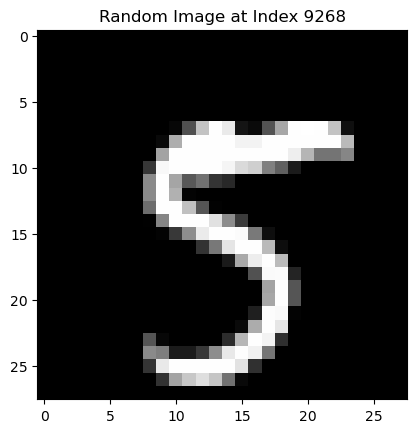

In [1]:
import pandas as pd
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Load MNIST CSV
file_path = "mnist_test.csv"  # Replace with your actual file path
mnist_data = pd.read_csv(file_path)

# Choose a random row index (skip the first column, which is the label
random_index = np.random.randint(0, len(mnist_data))  # Random index from 0 to len(dataset)-1

# Extract the selected row and reshape it to 28x28
random_image = mnist_data.iloc[random_index, 1:].values.reshape(28, 28).astype(np.uint8)  # Skip label column

# Convert to Pillow Image
img = Image.fromarray(random_image)

# Display the Random Image
plt.imshow(img, cmap="gray")
plt.title(f"Random Image at Index {random_index}")
plt.show()

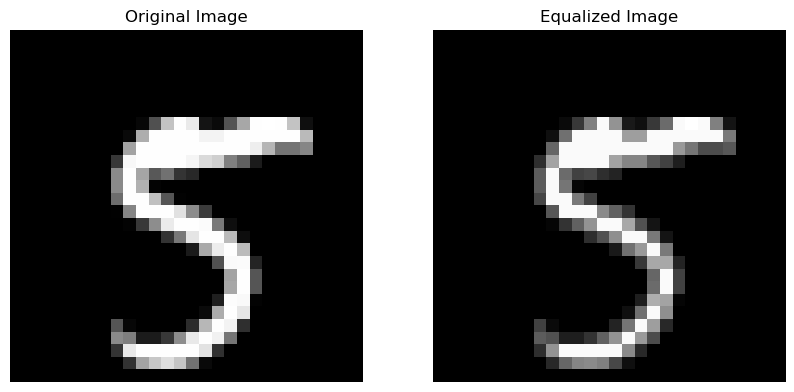

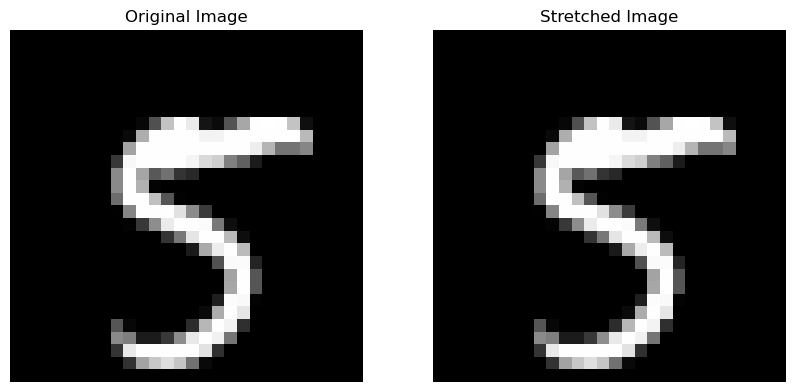

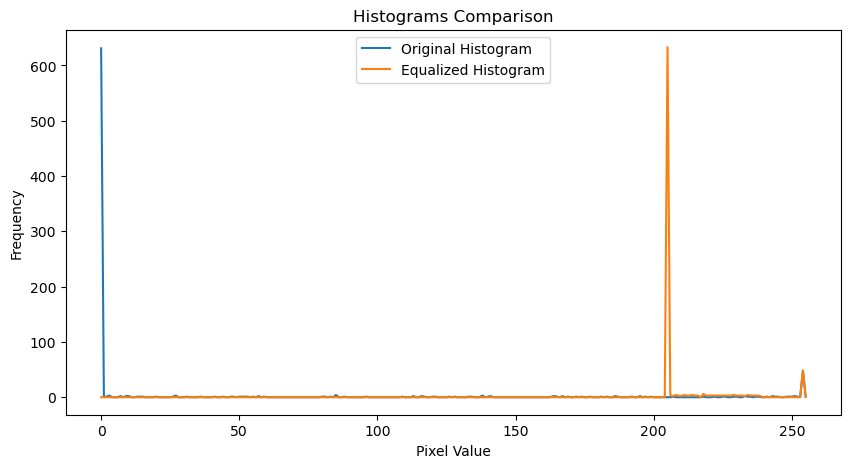

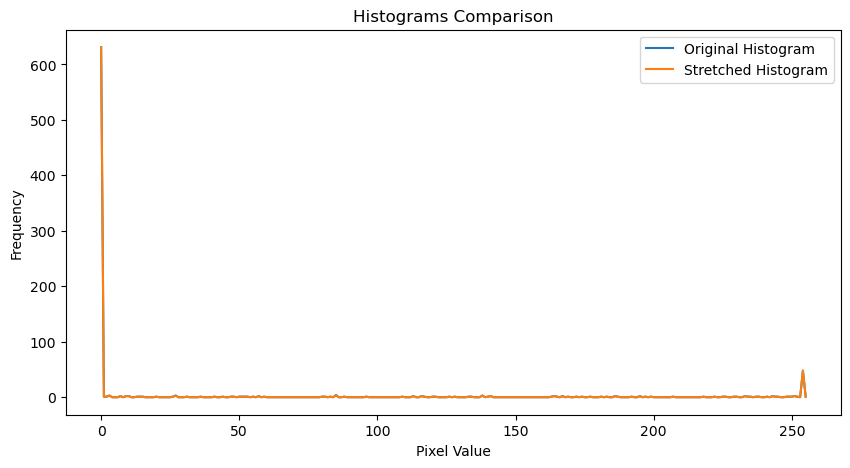

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Function to get the pixel frequency of an image
def get_pixel_frequency(image):
    pixel_frequency = np.zeros(256)
    for row in range(image.shape[0]):
        for col in range(image.shape[1]):
            pixel_val = image[row][col]
            pixel_frequency[pixel_val] += 1
    return pixel_frequency

# 2. Histogram Equalization function
def histogram_equalization(image):
    pixel_freq = get_pixel_frequency(image)
    pixel_pdf = pixel_freq / np.sum(pixel_freq)  # Probability Density Function
    pixel_cumsum = np.cumsum(pixel_pdf)  # Cumulative sum of PDF
    bits_cumsum = 255 * pixel_cumsum  # Normalize the cumulative sum to 255
    pixel_map = np.fix(bits_cumsum).astype(int)  # Create the pixel mapping
    equalized_image = np.zeros_like(image)

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            equalized_image[i, j] = pixel_map[image[i, j]]  # Apply the pixel mapping

    return equalized_image

# 3. Histogram Stretching function
def histogram_stretching(image):
    # Calculate the min and max pixel values of the image
    min_val = np.min(image)
    max_val = np.max(image)
    
    # Initialize an empty array with the same shape as the input image
    stretched_image = np.zeros_like(image, dtype=np.uint8)
    
    # Iterate through each pixel and apply the stretching formula
    for row in range(image.shape[0]):
        for col in range(image.shape[1]):
            pixel_val = image[row, col]
            stretched_image[row, col] = ((pixel_val - min_val) / (max_val - min_val)) * 255
            
    return stretched_image

# 4. Display Images Function
def display_image(image1, image2, title1, title2):
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(image1, cmap='gray')
    plt.title(title1)
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(image2, cmap='gray')
    plt.title(title2)
    plt.axis('off')
    plt.show()

# 5. Display Histograms Function
def display_histograms(histogram1, histogram2, title1, title2):
    plt.figure(figsize=(10, 5))
    plt.plot(histogram1, label=title1)
    plt.plot(histogram2, label=title2)
    plt.legend()
    plt.title('Histograms Comparison')
    plt.xlabel('Pixel Value')
    plt.ylabel('Frequency')
    plt.show()


# Perform Histogram Equalization and Stretching
equalized_image = histogram_equalization(random_image)
stretched_image = histogram_stretching(random_image)

# Display the original image vs equalized image
display_image(random_image, equalized_image, "Original Image", "Equalized Image")

# Display the original image vs stretched image
display_image(random_image, stretched_image, "Original Image", "Stretched Image")

# Get the histograms of the original and equalized images
original_hist = get_pixel_frequency(random_image)
equalized_hist = get_pixel_frequency(equalized_image)
stretched_hist = get_pixel_frequency(stretched_image)

# Display the histograms of the original and equalized images
display_histograms(original_hist, equalized_hist, "Original Histogram", "Equalized Histogram")

display_histograms(original_hist, stretched_hist, "Original Histogram", "Stretched Histogram")
